# Auditoría de fuga

```{admonition} Alcance
:class: tip
La sección 6.1 se calcula con el entrenamiento. La sección 6.2 resume revisiones hechas al construir
el panel sobre los datos originales de SAP; sus cifras no se pueden recalcular desde el panel,
porque las columnas con fuga ya no están en él.
```

Una variable tiene fuga cuando contiene información que no estaría disponible al momento de
predecir, casi siempre porque se registra a causa del desenlace. El síntoma típico es una variable
que predice demasiado bien. Aquí la predicción se hace el día 1 del mes *t* para la renuncia
durante ese mes; cualquier dato conocido después del día 1 es sospechoso.

## AUC univariado

Cada variable se usa sola como puntaje. Para las categóricas, el puntaje es la tasa de renuncia de
su categoría calculada en otros pliegues de personas (validación agrupada de cinco pliegues). Si se
calculara con las mismas filas, una categoría con una sola persona que renunció tendría una tasa de
100 % y un AUC inflado por sobreajuste. Un AUC de 0,5 equivale al azar, y uno mayor de 0,75 para una
sola variable sería sospechoso en un problema como este.

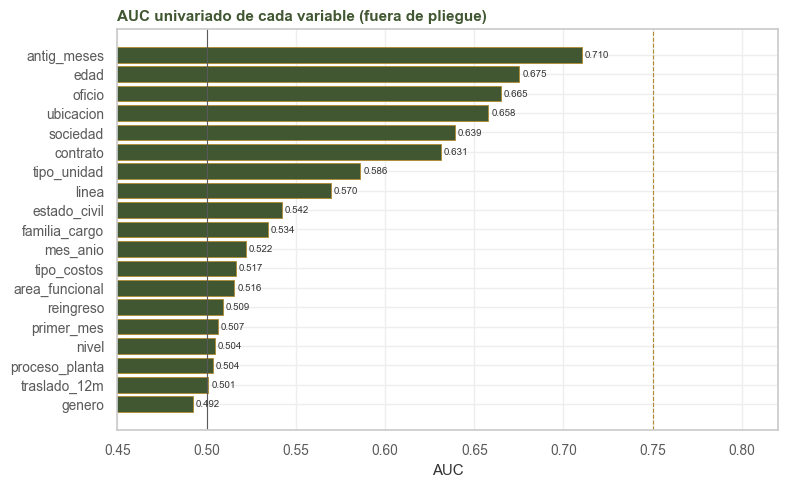

variable,AUC,dirección
antig_meses,0.710,"más bajo, más riesgo"
edad,0.675,"más bajo, más riesgo"
oficio,0.665,tasa de la categoría
ubicacion,0.658,tasa de la categoría
sociedad,0.639,tasa de la categoría
contrato,0.631,tasa de la categoría
tipo_unidad,0.586,tasa de la categoría
linea,0.570,tasa de la categoría
estado_civil,0.542,tasa de la categoría
familia_cargo,0.534,tasa de la categoría


In [1]:
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupKFold

sys.path.insert(0, '.')
warnings.filterwarnings('ignore')
from comun import (cargar, particion, estilo, etiquetar, OBJETIVO, NUM, BIN, PREDICTORAS,
                   VERDE, ORO, GRIS, BORDE)

estilo()

tr, _ = particion(cargar())
tr['mes_anio'] = tr.mes.str[5:]
y = tr[OBJETIVO].to_numpy()
pliegues = list(GroupKFold(5).split(tr, y, tr.persona_id))

filas = []
for v in PREDICTORAS + ['mes_anio']:
    if v in NUM or v in BIN:
        a = roc_auc_score(y, tr[v].fillna(tr[v].median()).to_numpy())
        direccion = 'más alto, más riesgo' if a >= 0.5 else 'más bajo, más riesgo'
        filas.append({'variable': v, 'AUC': max(a, 1 - a), 'dirección': direccion})
    else:
        # tasa de la categoría aprendida en los otros pliegues
        x = tr[v].fillna('(nulo)')
        puntaje = np.zeros(len(tr))
        for ent, val in pliegues:
            tasa_cat = tr.iloc[ent].groupby(x.iloc[ent])[OBJETIVO].mean()
            puntaje[val] = x.iloc[val].map(tasa_cat).fillna(y[ent].mean()).to_numpy()
        filas.append({'variable': v, 'AUC': roc_auc_score(y, puntaje),
                      'dirección': 'tasa de la categoría'})
auc = pd.DataFrame(filas).set_index('variable').sort_values('AUC', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
colores = [ORO if a > 0.75 else VERDE for a in auc.AUC[::-1]]
barras = ax.barh(auc.index[::-1], auc.AUC[::-1], color=colores, **BORDE)
etiquetar(ax, barras, '{:.3f}')
ax.axvline(0.5, c=GRIS, lw=0.8)
ax.axvline(0.75, c=ORO, ls='--', lw=0.8)
ax.set(xlim=(0.45, 0.82), title='AUC univariado de cada variable (fuera de pliegue)', xlabel='AUC')
plt.tight_layout()
plt.show()

auc.round(3)

Ninguna variable supera 0,75. La más alta es la antigüedad, con un AUC plausible para la variable
que más explica la renuncia (capítulo 3), y le sigue un grupo entre 0,6 y 0,7 que describe el puesto
y el lugar. Las que quedan en 0,5 o por debajo fuera de pliegue (`genero`, `nivel` y
`proceso_planta` sobre todo el panel) no tienen señal propia: la tasa aprendida en unos pliegues no
se repite en otros. No hay indicios de fuga y la señal está repartida entre varias variables.

## Fugas corregidas al construir el panel

El AUC univariado solo detecta la fuga que permanece en el panel. Las más importantes se
encontraron antes, al revisar cómo registra SAP cada salida, y se corrigieron en la construcción:

| campo | fuga | evidencia | corrección |
|---|---|---|---|
| cargo del mes *t* | en el mes de salida SAP libera la posición y el cargo queda vacío | vacío en el 100 % de los meses de salida y en el 0 % del resto | se usa el cargo del mes anterior (`cargo_t1`), del que salen `familia_cargo` y `oficio` |
| contrato | el reporte mensual toma el contrato vigente hoy y lo copia a todos los meses | ningún cambio de contrato en 16 años de historia dentro de un mismo número de personal | contrato vigente en cada mes según la historia de contratos de SAP; cambian 1.122 persona-mes (1,2 %) y aparecen 89 pasos de fijo a indefinido |
| tipo de personal | la base de costos de personal solo registra al personal activo y la ausencia de fila delata la salida | faltantes concentrados en los meses de salida | se recalcula con la misma regla contable sobre el centro de costo del mes, que siempre existe; coincide en el 99,99 % |
| centro de costo del mes *t* | podría cambiar o vaciarse al salir | vacío en el 0 % de las salidas; cambia en el 1,22 % de las salidas frente al 1,08 % del resto | se usa sin rezago |
| `evento`, `tipo_retiro` | describen la salida | por definición | fuera de las predictoras |

La fuga del contrato no se detectaba por su asociación con el objetivo; se identificó al revisar
cómo SAP construye el campo. Corregirla casi no cambió las tasas en el panel completo (término fijo
de 1,62 % a 1,60 %; indefinido de 0,40 % a 0,41 %), porque las conversiones a indefinido son pocas
en 20 meses. En una ventana más larga el sesgo habría sido mayor.

## Disponibilidad e identificadores

| variable | ¿se conoce el día 1 del mes *t*? |
|---|---|
| edad, antigüedad, género, estado civil, contrato, sociedad, ubicación, nivel, tipo de unidad, área, tipo de personal, proceso de planta | sí: foto del día 1 |
| familia, oficio | sí: cargo del mes *t−1* |
| primer_mes, reingreso | sí: dependen de meses anteriores |
| traslado_12m | sí: los 12 meses previos, sin incluir *t* |
| mes del año | sí |

`persona_id` no entra al modelo y solo agrupa en la validación. `mes` tampoco entra como tal; se usa
el mes del año, que es un efecto de calendario y no identifica el periodo. `evento`, `tipo_retiro` y
`y_renuncia` se construyen con la salida y quedan fuera de las predictoras. Los casi-duplicados
entre entrenamiento y test se discutieron en la sección 2.4.

## Variables descartadas o en observación

Además de las corregidas en la sección 6.2:

| variable | decisión | justificación |
|---|---|---|
| `funcion`, `cargo_t1`, `departamento`, `area` (textos SAP) | descartadas | redundantes con los ejes que se derivan de ellos (`nivel`, `familia_cargo`, `oficio`, `tipo_unidad`, `area_funcional`); además son cuasi-identificadores |
| `operacion_contable` | descartada | V de Cramér = 1 con `tipo_costos` |
| `categ_ceco` | descartada | V = 0,76 con `tipo_costos`, AUC de 0,506 y códigos sin significado documentado |
| `meses_en_sociedad` | descartada | Spearman de 0,93 con `antig_meses`; el traslado ya lo recoge `traslado_12m` |
| `pais`, `dpto_lugar` (origen) | descartadas | sin señal (AUC de 0,48 y 0,57, con 41 valores y 2.058 nulos) y países con una sola persona, con riesgo de reidentificación |
| `n_reingresos_previos` | transformada en `reingreso` (0/1) | el 92 % vale 0 |
| `primer_mes` | en observación | legítima (el ingreso se conoce el día 1), pero conviene verificar que no haya ingresos registrados después de la renuncia |
| `sociedad` | en observación | deriva entre periodos (PSI de 0,17, capítulo 5) por traslados de nómina |
| `genero` | en observación | sin señal propia (AUC de 0,49), pero muy desigual entre familias de cargo |

Queda un riesgo en la etiqueta: una renuncia registrada con retraso en SAP caería en el mes
equivocado. Por ese motivo se excluyeron los casos sin retiro registrado y los de periodo de prueba.

## Síntesis

- Ninguna variable del panel predice sola más de lo plausible (AUC máximo de la antigüedad).
- Las tres fugas encontradas en la fuente (cargo, contrato y tipo de personal) se corrigieron al
  construir el panel.
- Todas las predictoras se conocen el día 1 del mes que se predice.